# Optimisation Algorithms


In [2]:
import numpy as np
from numpy.typing import NDArray
from numpy.linalg import norm
import matplotlib.pyplot as plt
from typing import Callable, Union

In [19]:
def f(x, y) -> NDArray:
    return np.sin(x + 1) * np.sin(y - 1) * np.exp(-1/9 * (x**2 + y**2))

def grad_f(x, y) -> NDArray:
    x1 = np.cos(x + 1) * np.sin(y - 1) * np.exp(-1/9 * (x**2 + y**2)) \
       + np.sin(x + 1) * np.sin(y - 1) * -2/9 * x * np.exp(-1/9 * (x**2 + y**2))

    x2 = np.sin(x + 1) * np.cos(y - 1) * np.exp(-1/9 * (x**2 + y**2)) \
       + np.sin(x + 1) * np.sin(y - 1) * -2/9 * y * np.exp(-1/9 * (x**2 + y**2))

    return np.array([x1, x2])

## Optimisation Algorithms

In [101]:
def gradient_descent(learning_rate: np.float64, x0: NDArray, maxiters: int = 50) -> Union[NDArray, list[NDArray]]:
    x = x0
    history = np.zeros((2, maxiters))

    for i in range(maxiters):
        history[:, i] = x

        x = x - learning_rate * grad_f(x[0], x[1])

    return (x, history)

def stochastic_gradient_descent(learning_rate: np.float64, x0: NDArray, maxiters: int = 50) -> Union[NDArray, list[NDArray]]:
    x = x0
    history = np.zeros((2, maxiters))

    for i in range(maxiters):
        history[:, i] = x

        # simulate noise from estimating a single training example
        g = grad_f(x[0], x[1]) + np.random.normal(scale=0.1)
        x = x - learning_rate * g

    return (x, history)

def momentum(learning_rate: np.float64, momentum: np.float64, x0: NDArray, maxiters: int = 50) -> Union[NDArray, list[NDArray]]:
    x = x0
    history = np.zeros((2, maxiters))

    # velocity
    v = np.zeros((2,))

    for i in range(maxiters):
        history[:, i] = x

        # simulate noise from estimating a single training example
        g = grad_f(x[0], x[1]) + np.random.normal(scale=0.1)

        v = momentum * v - learning_rate * g
        x = x + v

    return (x, history)

def nag(learning_rate: np.float64, momentum: np.float64, x0: NDArray, maxiters: int = 50) -> Union[NDArray, list[NDArray]]:
    x = x0
    history = np.zeros((2, maxiters))

    # velocity
    v = np.zeros((2,))

    for i in range(maxiters):
        history[:, i] = x

        # trial step
        xdash = x - momentum * v

        # simulate noise from estimating a single training example
        g = grad_f(xdash[0], xdash[1]) + np.random.normal(scale=0.1)

        v = learning_rate * g

        x = x - v

    return (x, history)

def rprop(learning_rate: np.float64, x0: NDArray, maxiters: int = 50) -> Union[NDArray, list[NDArray]]:
    x = x0
    history = np.zeros((2, maxiters))

    learning_rate = learning_rate * np.ones((2, ))

    # simulate noise from estimating a single training example
    g = grad_f(x[0], x[1]) + np.random.normal(scale=0.1)

    for i in range(maxiters):
        history[:, i] = x

        if i > 0:
            # simulate noise from estimating a single training example
            gnew = grad_f(x[0], x[1]) + np.random.normal(scale=0.1)

            idx1 = gnew * g > 0
            idx2 = gnew * g < 0

            if idx1.any():
                learning_rate[idx1] = np.min(np.vstack((1.2 * learning_rate[idx1], 2 * np.ones((idx1.sum(), )))), axis=0)

            if idx2.any():
                learning_rate[idx2] = np.max(np.vstack((0.5 * learning_rate[idx2], 0 * np.ones((idx2.sum(), )))), axis=0)

        # simulate noise from estimating a single training example
        g = grad_f(x[0], x[1]) + np.random.normal(scale=0.1)

        x = x - learning_rate * np.sign(g)

    return (x, history)

## Compare Optimisation Algorithms

In [102]:
# Initial guess
x0 = np.array([-1.8, -0.3])

(gd_x, gd_history) = gradient_descent(0.5, x0, 10)
(sgd_x, sgd_history) = stochastic_gradient_descent(0.5, x0, 10)
(momentum_x, momentum_history) = momentum(0.5, 0.1, x0, 10)
(nag_x, nag_history) = nag(0.5, 0.1, x0, 10)
(rprop_x, rprop_history) = rprop(0.5, x0, 10)

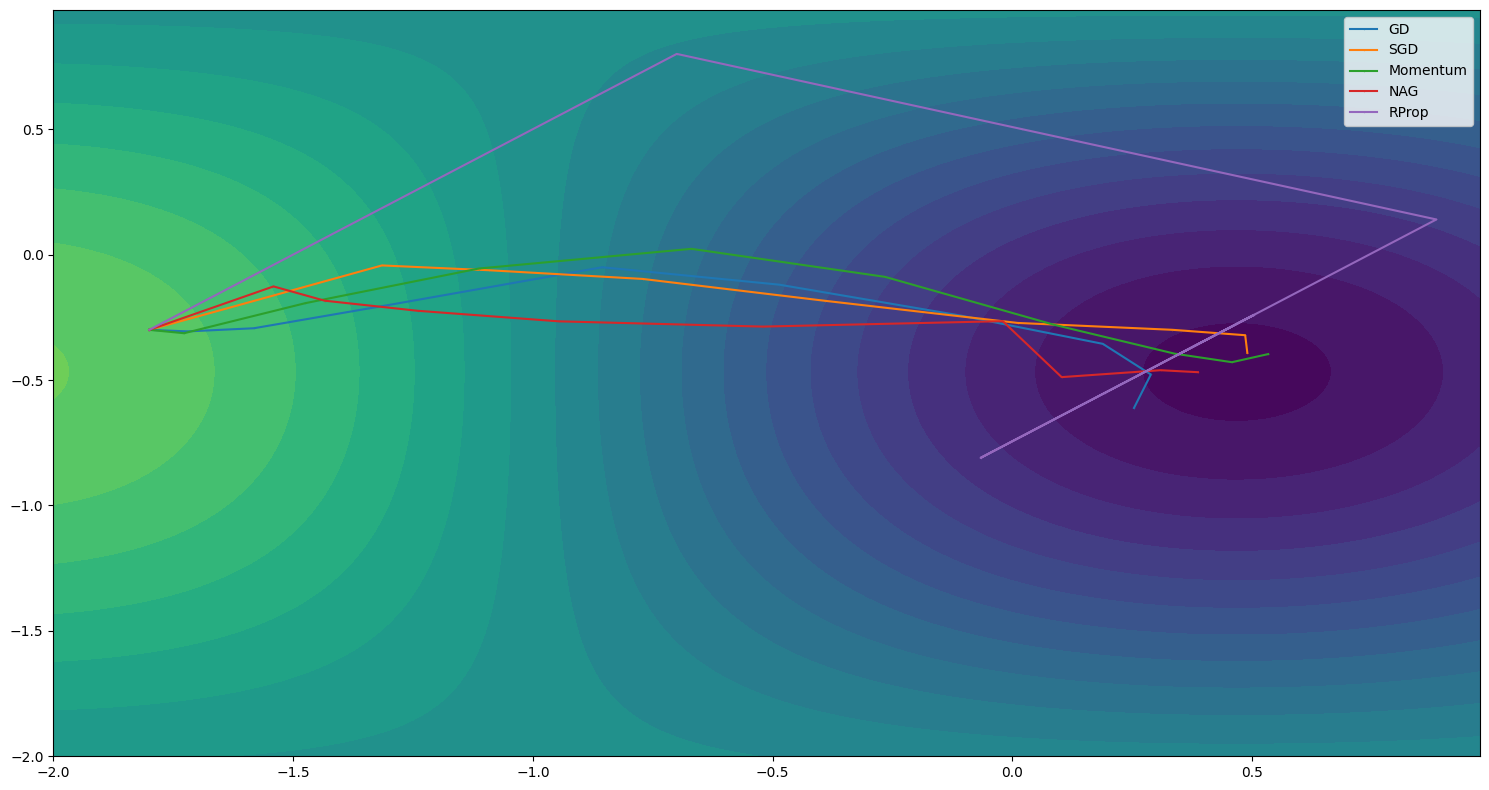

In [103]:
x = np.arange(-2, 1, 0.025)
y = np.arange(-2, 1, 0.025)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

fig, ax = plt.subplots(1, 1, figsize=(15, 8))
ax.contourf(X, Y, Z, levels=np.arange(-1, 1 + 0.08, 0.08))

ax.plot(gd_history[0, :], gd_history[1, :], marker="o", markersize=0.1, label="GD")
ax.plot(sgd_history[0, :], sgd_history[1, :], marker="o", markersize=0.1, label="SGD")
ax.plot(momentum_history[0, :], momentum_history[1, :], marker="o", markersize=0.1, label="Momentum")
ax.plot(nag_history[0, :], nag_history[1, :], marker="o", markersize=0.1, label="NAG")
ax.plot(rprop_history[0, :], rprop_history[1, :], marker="o", markersize=0.1, label="RProp")

ax.legend()
# ax.set_aspect(1)

fig.tight_layout()